# Importing Zenodo Reference Data

This notebook demonstrates how to load and plot reference PL spectra from:

> Tagarelli et al., *Electrical control of hybrid exciton transport in a van der Waals heterostructure*, **Nature Photonics** 2023  
> DOI: [10.1038/s41566-023-01198-w](https://doi.org/10.1038/s41566-023-01198-w)  
> Zenodo: [10.5281/zenodo.7660668](https://doi.org/10.5281/zenodo.7660668)

Two approaches are shown:
- **Part 1** — raw download from Zenodo (no preprocessing)
- **Part 2** — using `tmdc_optics_tools.reference` (after running `registry.py`)

Both produce identical plots. Part 2 is the recommended workflow.

---
## Part 1 — Raw Zenodo download

Downloads the zip directly from Zenodo, reads the `.mat` files into memory, and plots column 39 of the spectra array for each electric field condition.  
This approach requires knowing the internal structure of the Zenodo deposit.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import requests
import zipfile
import io
import scipy.io
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import seaborn as sns

In [ ]:
HEADERS = {"User-Agent": "LANES-Tools/1.0"}

url = "https://zenodo.org/records/7660668/files/Figure%201.zip?download=1"
r = requests.get(url, headers=HEADERS)

data = {}
with zipfile.ZipFile(io.BytesIO(r.content)) as z:
    mat_files = [n for n in z.namelist() if n.startswith("Figure 1d/") and n.endswith(".mat")]
    for name in mat_files:
        with z.open(name) as f:
            key = name.split("/")[-1]
            data[key] = scipy.io.loadmat(io.BytesIO(f.read()))

for filename, mat in data.items():
    keys = [k for k in mat.keys() if not k.startswith("_")]
    print(f"{filename}: {keys}")

hb_0field.mat: ['I', 'M', 'dp', 'energy', 'energy_max_zeroef', 'int_pl', 'int_range', 'power', 'None', 'spectra']
homobilayer_ef300_power_spectral.mat: ['ans', 'b_hbn_thick', 'd', 'dipole_moment', 'e_charge', 'energy', 'eps_0', 'eps_hbn', 'eps_tmdc', 'None', 'ii', 'index_2_sum', 'power', 'power_rounded', 'spectra', 'spectra_sum', 'spectra_sum_norm', 't_hbn_thick', 'u']
homobilayer_efm300_spectral.mat: ['I', 'M', 'd', 'energy', 'energy_max', 'None', 'int_pl', 'int_range', 'power', 'spectra']


c:\Users\Brandon\anaconda3\envs\viz-sci-plot\Lib\site-packages\scipy\io\matlab\_mio.py:236: MatReadWarning: Duplicate variable name "None" in stream - replacing previous with new
Considerscipy.io.matlab.varmats_from_mat to split file into single variable files
  matfile_dict = MR.get_variables(variable_names)


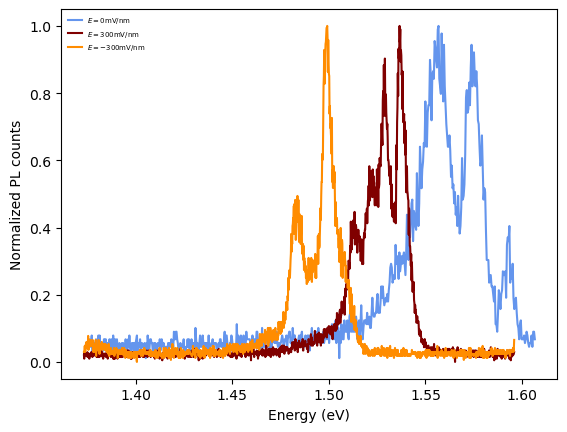

In [ ]:
hb_ef300  = data['homobilayer_ef300_power_spectral.mat']
hb_efm300 = data['homobilayer_efm300_spectral.mat']
hb_ef0    = data['hb_0field.mat']

# Column 39 — nearest index to ~40 µW excitation power across all three files
# ef0: 28.6 µW, ef+300: 40.4 µW, ef-300: 77.6 µW (power axes are not aligned)
hb_ef300_norm  = (hb_ef300['spectra'][:,39]  - np.min(hb_ef300['spectra'][:,39]))  / (np.max(hb_ef300['spectra'][:,39])  - np.min(hb_ef300['spectra'][:,39]))
hb_efm300_norm = (hb_efm300['spectra'][:,39] - np.min(hb_efm300['spectra'][:,39])) / (np.max(hb_efm300['spectra'][:,39]) - np.min(hb_efm300['spectra'][:,39]))
hb_ef0_norm    = (hb_ef0['spectra'][:,39]    - np.min(hb_ef0['spectra'][:,39]))    / (np.max(hb_ef0['spectra'][:,39])    - np.min(hb_ef0['spectra'][:,39]))

fig, ax = plt.subplots()

# Energy slices follow the original authors' plotting code (removes noisy edges)
ax.plot(hb_ef0['energy'][290:-420],    hb_ef0_norm[290:-420],    color='cornflowerblue', linestyle='-', label='$E=0$ mV/nm')
ax.plot(hb_ef300['energy'][10:-10],    hb_ef300_norm[10:-10],    color='maroon',         linestyle='-', label='$E=+300$ mV/nm')
ax.plot(hb_efm300['energy'][10:-10],   hb_efm300_norm[10:-10],   color='darkorange',     linestyle='-', label='$E=-300$ mV/nm')

ax.set_xlabel('Energy (eV)')
ax.set_ylabel('Normalised PL counts')
ax.legend(loc='upper left', frameon=False, fontsize=5)
ax.set_title('Tagarelli 2023 — Figure 1d (raw)')
plt.tight_layout()
plt.show()

---
## Part 2 — Using `tmdc_optics_tools.reference`

**Prerequisites:** run the registry script once to download and process the data:
```bash
python -m tmdc_optics_tools.reference.registry
```
This saves a processed `.h5` file to `src/tmdc_optics_tools/reference/data/`.  
After that, loading is instant and requires no knowledge of the original file structure.

In [ ]:
from tmdc_optics_tools.reference.loader import load_reference

ref = load_reference("2L_WSe2", "Tagarelli2023")

# Dataset-level metadata
print(ref)
print(f"\nTitle      : {ref.title}")
print(f"DOI        : {ref.doi}")
print(f"Dataset     : {ref.dataset_doi}")
print(f"Measurement: {ref.spectroscopy}")

ReferenceDataset(material='WSe2_bilayer', source='Tagarelli2023', spectroscopy='PL', sweeps={'electric_field': 3})

Title      : Electrical control of hybrid exciton transport in a van der Waals heterostructure
DOI        : 10.1038/s41566-023-01198-w
Dataset     : 10.5281/zenodo.7660668
Measurement: PL


In [ ]:
# Inspect the sweep structure
ef_sweep = ref["electric_field"]
print(f"Outer sweep  : {ef_sweep.parameter_name} ({ef_sweep.parameter_unit})")
print(f"Field values : {ef_sweep.values()}")
print(f"Default field: {ef_sweep.default_value} {ef_sweep.parameter_unit}")

for field_val in ef_sweep.values():
    cond = ef_sweep[field_val]
    pw   = cond["power"]
    print(f"  E={field_val:+.0f} mV/nm — {len(pw.spectra)} power steps, "
          f"default={pw.default_value:.1f} {pw.parameter_unit}")

Outer sweep  : electric_field (mV/nm)
Field values : [-300.0, 0.0, 300.0]
Default field: 0.0 mV/nm
  E=-300 mV/nm — 83 power steps, default=36.7 uW
  E=+0 mV/nm — 70 power steps, default=36.4 uW
  E=+300 mV/nm — 82 power steps, default=40.4 uW


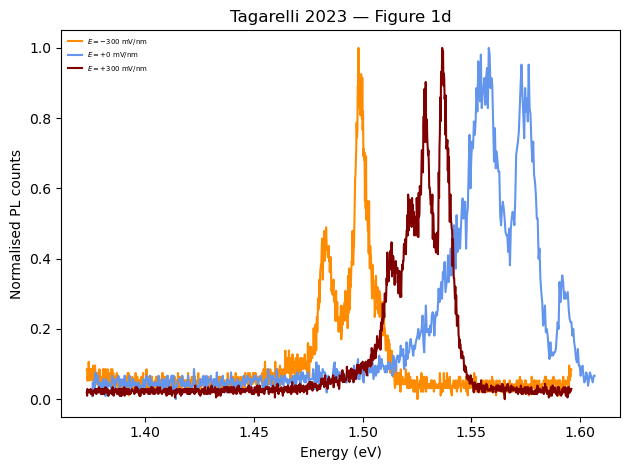

In [ ]:
# Reproduce Figure 1d — default power for each electric field condition
colors = {0.0: 'cornflowerblue', 300.0: 'maroon', -300.0: 'darkorange'}

fig, ax = plt.subplots()

for field_val in ef_sweep.values():
    cond = ef_sweep[field_val]
    sp   = cond.default_spectrum("power")
    ax.plot(
        sp.energy,
        sp.normalised(),
        color=colors[field_val],
        linestyle='-',
        label=f'$E={field_val:+.0f}$ mV/nm'
    )

ax.set_xlabel(f'Energy ({sp.energy_unit})')
ax.set_ylabel(f'Normalised {sp.spectroscopy} counts')
ax.legend(loc='upper left', frameon=False, fontsize=5)
ax.set_title(f'Tagarelli 2023 — Figure 1d')
plt.tight_layout()
plt.show()

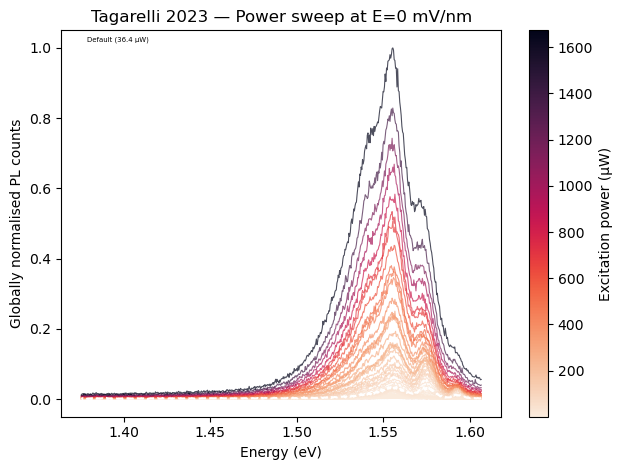

In [ ]:
cond     = ef_sweep[0.0]
pw_sweep = cond["power"]

all_spectra = pw_sweep.all_spectra()

# Global normalisation
global_min = min(sp.intensity.min() for sp in all_spectra)
global_max = max(sp.intensity.max() for sp in all_spectra)

# Colormap scaled to power axis
power_values = [sp.parameter_value for sp in all_spectra]
norm_cmap    = mcolors.Normalize(vmin=min(power_values), vmax=max(power_values))
cmap         = sns.color_palette("rocket_r", as_cmap=True)

fig, ax = plt.subplots()

for sp in all_spectra:
    norm  = (sp.intensity - global_min) / (global_max - global_min)
    color = cmap(norm_cmap(sp.parameter_value))
    ax.plot(sp.energy, norm, color=color, alpha=0.7, linewidth=0.8)

# Highlight the default
sp_default   = pw_sweep.default()
norm_default = (sp_default.intensity - global_min) / (global_max - global_min)
ax.plot(sp_default.energy, norm_default,
        color='white', linewidth=1.5, linestyle='--',
        label=f'Default ({sp_default.parameter_value:.1f} µW)')

# Colorbar
sm = cm.ScalarMappable(cmap=cmap, norm=norm_cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label('Excitation power (µW)')

ax.set_xlabel(f'Energy ({sp_default.energy_unit})')
ax.set_ylabel(f'Globally normalised {sp_default.spectroscopy} counts')
ax.legend(loc='upper left', frameon=False, fontsize=5)
ax.set_title('Tagarelli 2023 — Power sweep at E=0 mV/nm')
plt.tight_layout()
plt.show()